<div style="text-align:center;">

<h1 style="color:#4aa3ff;">📧 Email Phishing Detection Using Machine Learning</h1>

<p style="color:gray; font-size:16px;">
                   Comparative analysis of multiple models to identify the most accurate and reliable solution
</p>

<hr style="border:1px solid gray;">

</div>

<div style="text-align:center;">

<hr style="border:1px solid gray;">

<h2 style="color:#4aa3ff;">1️⃣ IMPORTING LIBRARIES & DEPENDENCIES</h2>

<p style="color:lightgray; font-size:16px;">
Importing essential libraries for data processing, machine learning, imbalance handling, and visualization
</p>

<hr style="border:1px solid gray;">

</div>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

<div style="text-align:center;">

<hr style="border:1px solid gray;">

<h2 style="color:#4aa3ff;">2️⃣ DATA LOADING & OVERVIEW</h2>

<p style="color:lightgray; font-size:16px;">
Loading and exploring the combined phishing email dataset for analysis and model training
</p>

<p style="color:lightgray; font-size:14px;">
📂 Dataset Sources: 
<a href="https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset" target="_blank" style="color:#4aa3ff;">
Phishing Email Dataset
</a> 
& 
<a href="https://www.kaggle.com/datasets/wcukierski/enron-email-dataset" target="_blank" style="color:#4aa3ff;">
Enron Email Dataset
</a>
</p>

<hr style="border:1px solid gray;">

</div>

In [2]:
df = pd.read_csv("email_phishing_data.csv")

print(df.columns)
df.head()

Index(['num_words', 'num_unique_words', 'num_stopwords', 'num_links',
       'num_unique_domains', 'num_email_addresses', 'num_spelling_errors',
       'num_urgent_keywords', 'label'],
      dtype='object')


,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,52,0,0,0,0,0,0
1,5,5,1,0,0,0,0,0,0
2,34,32,15,0,0,0,0,0,0
3,6,6,2,0,0,0,0,0,0
4,9,9,2,0,0,0,0,0,0


<div style="text-align:center;">

<hr style="border:1px solid gray;">

<h2 style="color:#4aa3ff;">3️⃣ DATA PREPROCESSING, CLEANING & INITIAL ANALYSIS</h2>

<p style="color:lightgray; font-size:16px;">
Cleaning the dataset by removing unnecessary columns, handling missing values, eliminating duplicates, and analyzing class distribution
</p>

<hr style="border:1px solid gray;">

</div>

In [3]:
# Drop unnecessary columns safely
df = df.drop(columns=['source'], errors='ignore')

# Remove missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Check distribution
print(df['label'].value_counts())

label
0    198971
1      6081
Name: count, dtype: int64


<div style="text-align:center;">

<hr style="border:1px solid gray;">

<h2 style="color:#4aa3ff;">4️⃣ FEATURE SELECTION & DATA BALANCING</h2>

<p style="color:lightgray; font-size:16px;">
Separating features and target variable, followed by applying SMOTE to handle class imbalance and improve model performance
</p>

<hr style="border:1px solid gray;">

</div>

In [4]:
X = df.drop('label', axis=1)
y = df['label']

from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

<div style="text-align:center;">

<hr style="border:1px solid gray;">

<h2 style="color:#4aa3ff;">5️⃣ TRAIN-TEST SPLITTING (BALANCED DATA)</h2>

<p style="color:lightgray; font-size:16px;">
Splitting the balanced dataset into training and testing sets while maintaining class distribution for reliable model evaluation
</p>

<hr style="border:1px solid gray;">

</div>

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

<div style="text-align:center;">

<hr style="border:1px solid gray;">

<h2 style="color:#4aa3ff;">6️⃣ MODEL INITIALIZATION & HYPERPARAMETER TUNING</h2>

<p style="color:lightgray; font-size:16px;">
Initializing machine learning models and configuring optimized hyperparameters to improve phishing detection performance
</p>

<hr style="border:1px solid gray;">

</div>

In [16]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        n_estimators=300,
        max_depth=7,
        learning_rate=0.08,
        random_state=42
    )
}

<div style="text-align:center;">

<hr style="border:1px solid gray;">

<h2 style="color:#4aa3ff;">7️⃣ MODEL TRAINING, EVALUATION & PERFORMANCE COMPARISON</h2>

<p style="color:lightgray; font-size:16px;">
Training machine learning models on the balanced dataset and evaluating their performance using accuracy, precision, recall, and F1-score for comparison
</p>

<hr style="border:1px solid gray;">

</div>

In [17]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name} Accuracy: {acc}")
    print(classification_report(y_test, y_pred))


Random Forest Accuracy: 0.9556471371671965
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     39795
           1       0.94      0.97      0.96     39794

    accuracy                           0.96     79589
   macro avg       0.96      0.96      0.96     79589
weighted avg       0.96      0.96      0.96     79589


XGBoost Accuracy: 0.8542763447210041
              precision    recall  f1-score   support

           0       0.90      0.80      0.85     39795
           1       0.82      0.91      0.86     39794

    accuracy                           0.85     79589
   macro avg       0.86      0.85      0.85     79589
weighted avg       0.86      0.85      0.85     79589



<div style="text-align:center;">

<hr style="border:1px solid gray;">

<h2 style="color:#4aa3ff;">8️⃣ MODEL PERFORMANCE VISUALIZATION & COMPARATIVE ANALYSIS</h2>

<p style="color:lightgray; font-size:16px;">
Visualizing and comparing the performance of different machine learning models using graphical representations for better interpretability
</p>

<hr style="border:1px solid gray;">

</div>

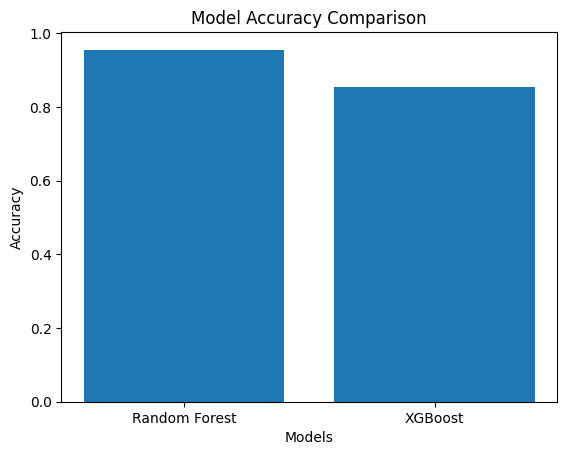

In [18]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

<div style="text-align:center;">

<hr style="border:1px solid gray;">

<h2 style="color:#4aa3ff;">9️⃣ OPTIMAL MODEL SELECTION & FINALIZATION</h2>

<p style="color:lightgray; font-size:16px;">
Selecting the best-performing model based on evaluation metrics and finalizing it for deployment and prediction
</p>

<hr style="border:1px solid gray;">

</div>

In [19]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

best_model.fit(X_train, y_train)

print("Best Model:", best_model_name)
print("Accuracy:", results[best_model_name])

Best Model: Random Forest
Accuracy: 0.9556471371671965


<div style="text-align:center;">

<hr style="border:1px solid gray;">

<h2 style="color:#4aa3ff;">🔟 CONFUSION MATRIX ANALYSIS & MODEL EVALUATION</h2>

<p style="color:lightgray; font-size:16px;">
Analyzing model performance using a confusion matrix to evaluate true positives, false positives, false negatives, and overall classification effectiveness
</p>

<hr style="border:1px solid gray;">

</div>

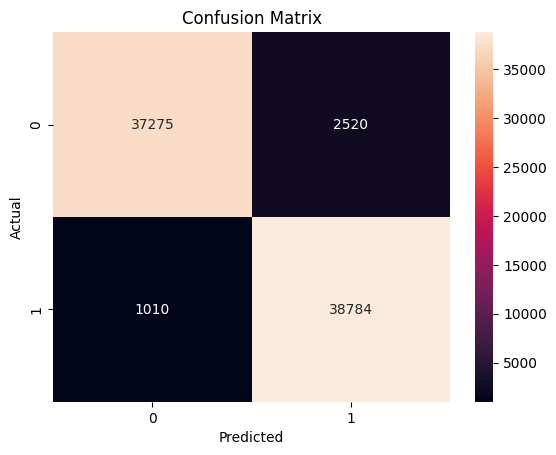

In [20]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

<div style="text-align:center;">

<hr style="border:1px solid gray;">

<h2 style="color:#4aa3ff;">1️⃣1️⃣ MODEL SAVING, SERIALIZATION & DEPLOYMENT PREPARATION</h2>

<p style="color:lightgray; font-size:16px;">
Saving the trained model and associated components for future use and preparing it for real-world deployment and integration
</p>

<hr style="border:1px solid gray;">

</div>

In [21]:
import joblib

# Save ONLY the model
joblib.dump(best_model, "email_phishing_model_final.pkl", compress=3)

print("Model saved successfully!")

Model saved successfully!


<div style="text-align:center;">

<hr>

<h2 style="color:#4aa3ff;">1️⃣2️⃣ CONCLUSION</h2>

<p style="color:lightgray; font-size:16px;">
After training and evaluating multiple machine learning models, Random Forest emerged as the best-performing model for phishing email detection.
</p>

<p style="color:lightgray; font-size:16px;">
The model achieved an accuracy of <b>~95.6%</b>, demonstrating strong capability in distinguishing between legitimate and phishing emails.
</p>

<p style="color:lightgray; font-size:16px;">
To address the class imbalance in the dataset, SMOTE was applied, which significantly improved the model’s ability to detect phishing emails more effectively.
</p>

<p style="color:lightgray; font-size:16px;">
Unlike text-based approaches, this model leverages engineered numerical features, making it efficient and suitable for real-time phishing detection systems.
</p>

<p style="color:lightgray; font-size:16px;">
Overall, the developed system provides a robust and scalable solution for detecting phishing emails with high accuracy and improved reliability.
</p>

<hr>

</div>